In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [2]:
df = pd.read_csv(
    "../data/raw/household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)


In [3]:
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [5]:
df.isna().sum()


Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [6]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.drop(["Date", "Time"], axis=1, inplace=True)
df.set_index("datetime", inplace=True)


In [7]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [9]:
df = df.ffill()
df = df.dropna()


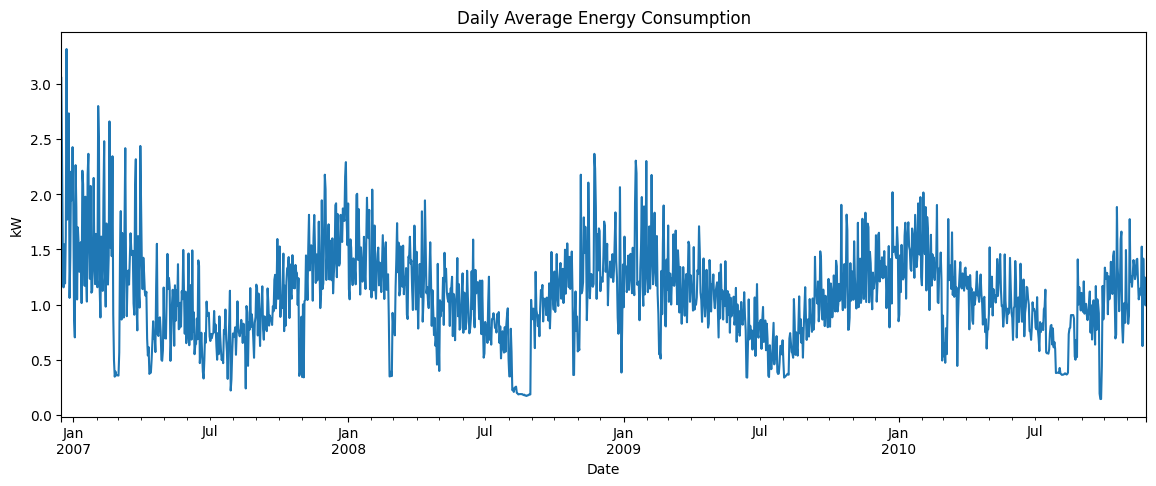

In [10]:
plt.figure(figsize=(14, 5))
df["Global_active_power"].resample("D").mean().plot()
plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("kW")
plt.show()


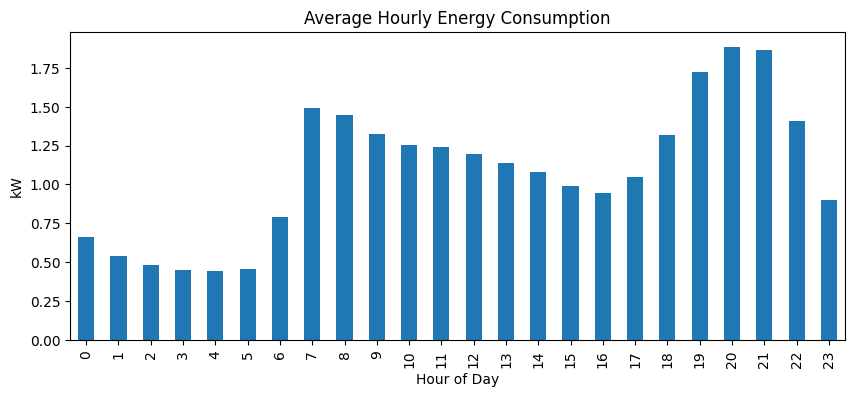

In [11]:
hourly_avg = df.groupby(df.index.hour)["Global_active_power"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(kind="bar")
plt.title("Average Hourly Energy Consumption")
plt.xlabel("Hour of Day")
plt.ylabel("kW")
plt.show()


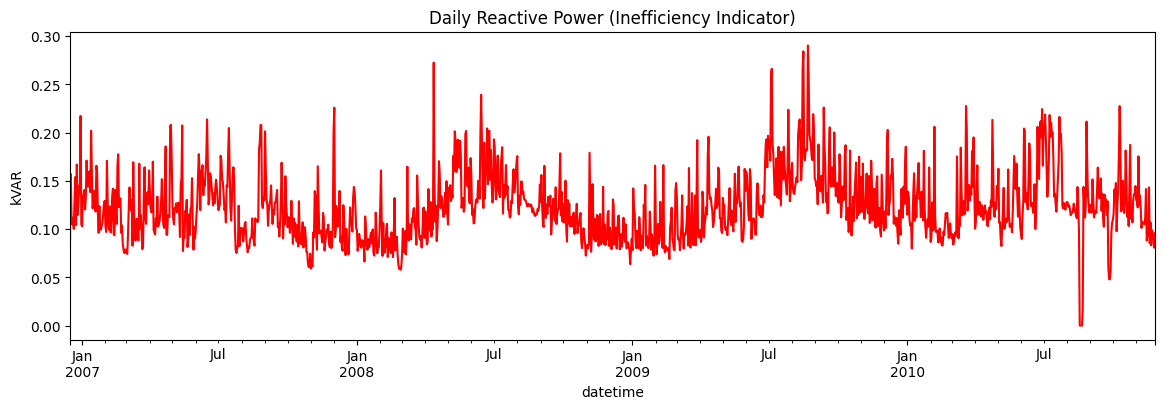

In [12]:
plt.figure(figsize=(14, 4))
df["Global_reactive_power"].resample("D").mean().plot(color="red")
plt.title("Daily Reactive Power (Inefficiency Indicator)")
plt.ylabel("kVAR")
plt.show()


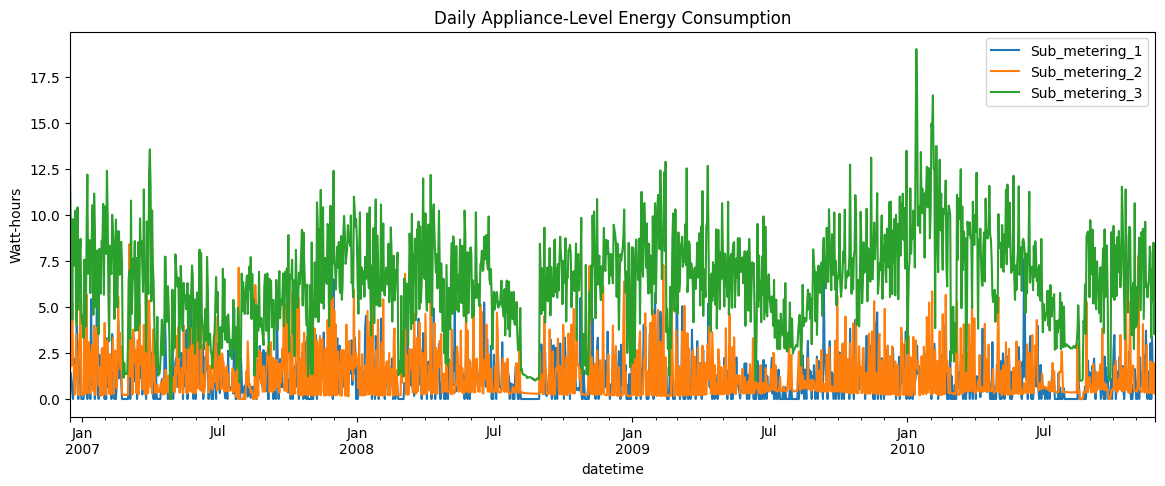

In [13]:
sub_meter_cols = [
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[sub_meter_cols].resample("D").mean().plot(figsize=(14, 5))
plt.title("Daily Appliance-Level Energy Consumption")
plt.ylabel("Watt-hours")
plt.show()


In [14]:
df.to_csv("../data/processed/energy_cleaned.csv")
